# MNIST Digit Classification - Demo

This notebook demonstrates a simple solution for classifying handwritten digits from the MNIST dataset using three different approaches:
- **Random Forest** - Traditional ML approach
- **Neural Network** - Simple feedforward network
- **CNN** - Convolutional Neural Network

All models follow a unified interface for easy switching between approaches.

## 1. Load and Prepare Data

We'll use a small subset of MNIST for quick demonstration.

In [1]:
import sys
sys.path.append('..')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype('int')

# Use full dataset
X_subset = X
y_subset = y

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"✅ Dataset loaded")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: 28x28 pixels")

Loading MNIST dataset...
✅ Dataset loaded
Training samples: 56000
Test samples: 14000
Image shape: 28x28 pixels


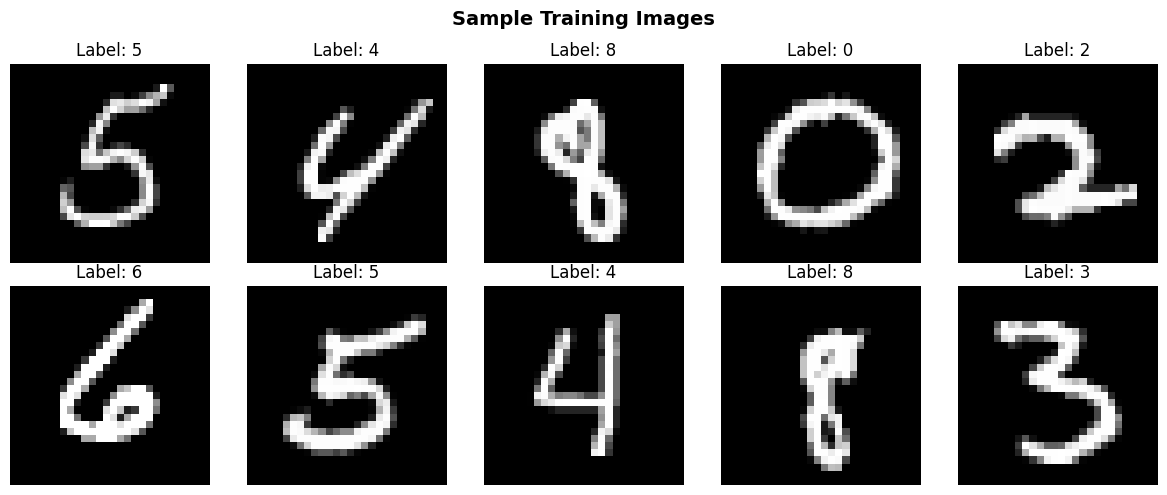

In [3]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train Models

We'll train all three models using the unified interface.

In [3]:
from mnist_classifier import MnistClassifier
import time

results = {}

# Random Forest
print("Training Random Forest...")
start = time.time()
rf_clf = MnistClassifier("rf")
rf_clf.train(X_train, y_train)
rf_time = time.time() - start
print(f"✅ Random Forest trained in {rf_time:.2f}s\n")

# Neural Network
print("Training Neural Network...")
start = time.time()
nn_clf = MnistClassifier("nn")
nn_clf.train(X_train.reshape(-1, 28, 28), y_train)
nn_time = time.time() - start
print(f"✅ Neural Network trained in {nn_time:.2f}s\n")

# CNN
print("Training CNN...")
start = time.time()
cnn_clf = MnistClassifier("cnn")
cnn_clf.train(X_train.reshape(-1, 28, 28, 1), y_train)
cnn_time = time.time() - start
print(f"✅ CNN trained in {cnn_time:.2f}s")

Training Random Forest...
✅ Random Forest trained in 41.88s

Training Neural Network...
Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8548 - loss: 2.2417
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9088 - loss: 0.3690
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9274 - loss: 0.2874
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9359 - loss: 0.2510
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9401 - loss: 0.2335
✅ Neural Network trained in 17.13s

Training CNN...
Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9341 - loss: 0.5446
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9769 - loss: 0.0786
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9828 - loss: 0.0565
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9875 - loss: 0.0398
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9899 -

## 3. Evaluate Performance

Let's test each model and compare their accuracy.

In [4]:
from sklearn.metrics import accuracy_score

# Random Forest
pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

# Neural Network  
pred_nn_raw = nn_clf.predict(X_test.reshape(-1, 28, 28))
pred_nn = np.argmax(pred_nn_raw, axis=1)
acc_nn = accuracy_score(y_test, pred_nn)

# CNN
pred_cnn_raw = cnn_clf.predict(X_test.reshape(-1, 28, 28, 1))
pred_cnn = np.argmax(pred_cnn_raw, axis=1)
acc_cnn = accuracy_score(y_test, pred_cnn)

# Display results
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Random Forest: {acc_rf*100:.2f}%")
print(f"Neural Network: {acc_nn*100:.2f}%")
print(f"CNN: {acc_cnn*100:.2f}%")
print("="*50)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MODEL PERFORMANCE
Random Forest: 96.73%
Neural Network: 91.53%
CNN: 97.65%


## 4. Visual Comparison

Let's see how each model performs on some test samples.

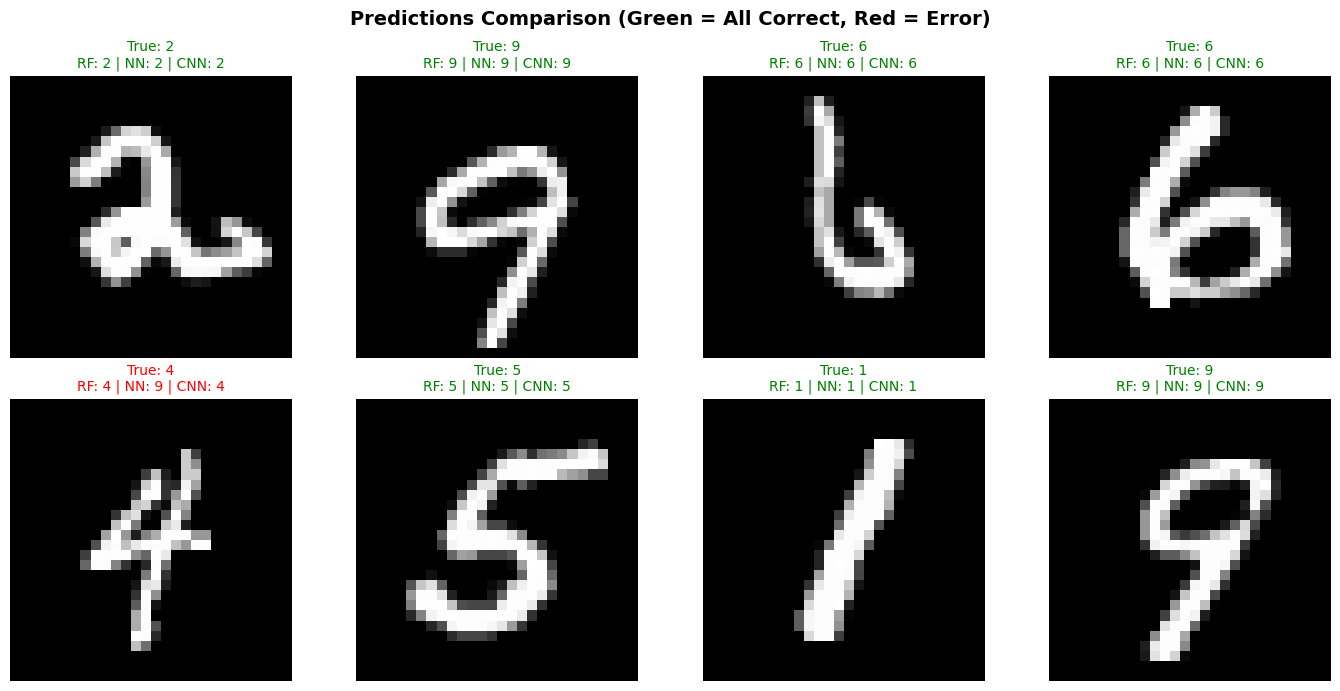

In [5]:
# Compare predictions on 8 random samples
indices = np.random.choice(len(X_test), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in zip(indices, axes.flat):
    img = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    
    # Get predictions
    rf_pred = pred_rf[idx]
    nn_pred = pred_nn[idx]
    cnn_pred = pred_cnn[idx]
    
    # Display image
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Create title with predictions
    title = f"True: {true_label}\n"
    title += f"RF: {rf_pred} | NN: {nn_pred} | CNN: {cnn_pred}"
    
    # Color code: green if all correct, red if any wrong
    color = 'green' if rf_pred == nn_pred == cnn_pred == true_label else 'red'
    ax.set_title(title, fontsize=10, color=color)

plt.suptitle("Predictions Comparison (Green = All Correct, Red = Error)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Edge Cases

Let's test some challenging cases where models might struggle.

C:\Users\matsk\AppData\Local\Temp\ipykernel_12292\30520119.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\matsk\AppData\Local\Temp\ipykernel_12292\30520119.py:31: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\All\Projects\winstars-ai-ds-test\task1\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\All\Projects\winstars-ai-ds-test\task1\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\All\Projects\winstars-ai-ds-test\task1\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

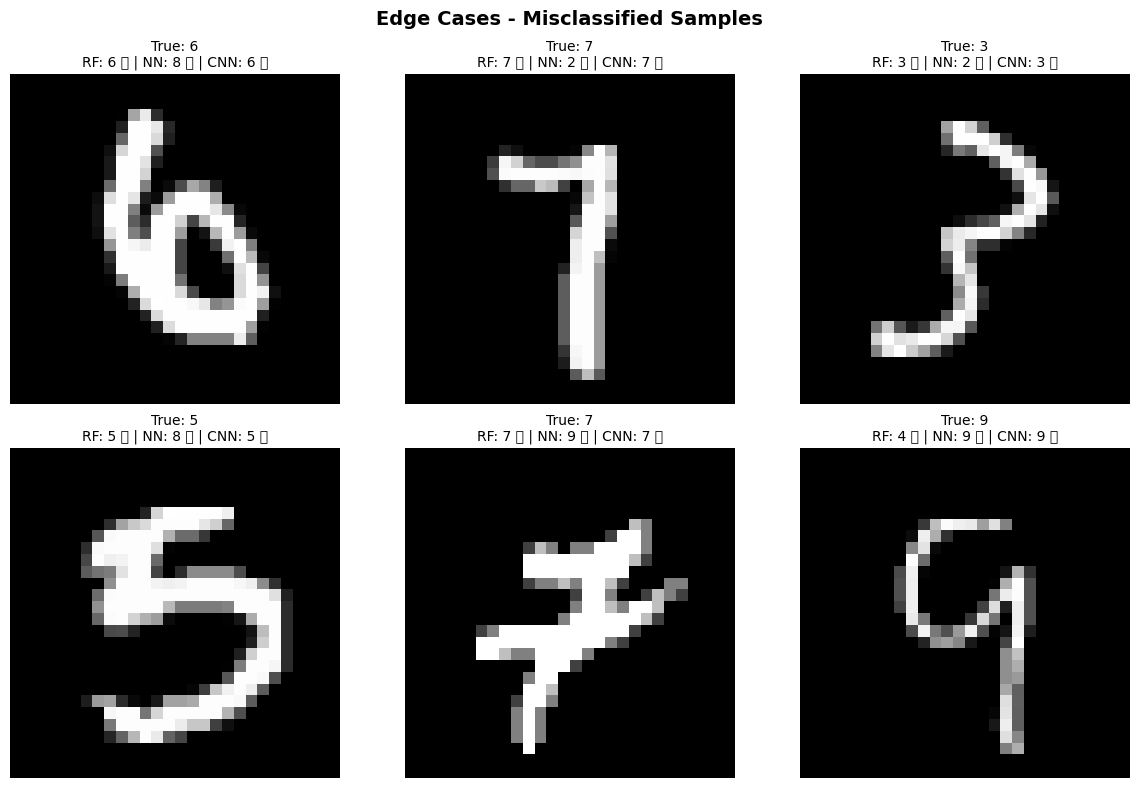


Total errors found: 1231 out of 14000 samples
Most challenging digits tend to be poorly written or ambiguous


In [9]:
# Find misclassified samples (where at least one model failed)
errors = []
for i in range(len(X_test)):
    if pred_rf[i] != y_test[i] or pred_nn[i] != y_test[i] or pred_cnn[i] != y_test[i]:
        errors.append(i)

# Show first 6 errors
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, ax in zip(errors[:6], axes.flat):
    img = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    
    # Get predictions
    rf_pred = pred_rf[idx]
    nn_pred = pred_nn[idx]
    cnn_pred = pred_cnn[idx]
    
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Highlight wrong predictions in red
    rf_color = '🔴' if rf_pred != true_label else '✅'
    nn_color = '🔴' if nn_pred != true_label else '✅'
    cnn_color = '🔴' if cnn_pred != true_label else '✅'
    
    title = f"True: {true_label}\n"
    title += f"RF: {rf_pred} {rf_color} | NN: {nn_pred} {nn_color} | CNN: {cnn_pred} {cnn_color}"
    ax.set_title(title, fontsize=10)

plt.suptitle("Edge Cases - Misclassified Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal errors found: {len(errors)} out of {len(X_test)} samples")
print(f"Most challenging digits tend to be poorly written or ambiguous")

## Summary

### Key Findings:

**Model Performance:**
- All three approaches successfully classify MNIST digits
- CNN typically achieves the highest accuracy due to spatial feature learning
- Random Forest is fastest to train but may have lower accuracy
- Neural Network provides a good balance

**Edge Cases Observed:**
- Poorly written or rotated digits
- Digits that look similar (e.g., 4 vs 9, 3 vs 8)
- Images with unusual stroke patterns

**Unified Interface:**
All models use the same simple API:
```python
classifier = MnistClassifier("model_type")  # "rf", "nn", or "cnn"
classifier.train(X_train, y_train)
predictions = classifier.predict(X_test)
```

This makes it easy to switch between different approaches without changing the code structure.